In [15]:
### Bone to predict:
BONE = 'tibia'

### Change to older model that does not record the CT_PO:
OLDER_MACHINE = True

### Add mechanography features:
ADD_MECHANOGRAPHY = False

### Remove Miki
REMOVE_MIKI = True

In [16]:
from sklearn.linear_model import ElasticNet, LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import PrecisionRecallDisplay
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [17]:
raw_motion_data = pd.read_excel("data/Motion full matched_for_olga.xlsx", header=1)

In [18]:
motion_data = raw_motion_data.replace('-', np.nan)
radius_columns = ['Tt.BMD', 'Tt.Ar', 'Tb.BMD', 'BV/TV', 'Tb.N', 'Tb.Th', 'Tb.Sp', 'Tb.1/N.SD', 'Tb.Ar', 'Ct.BMD', 'Ct.Th', 'Ct.Po', 'Ct.Po.Dm', 'Ct.Pm', 'Ct.Ar']
mechanography_columns = ['GRF', 'f max', 'f max rel', 'CRT tpr', 'PLEO', 'PLEC', 'EAEO', 'EAEC', 'VREO', 'VREC']
remove_features = []

grader_column = f'MG_{BONE}_rounded mean'

if REMOVE_MIKI:
    grader_column = f'MG_{BONE}_rounded mean no Miki'
    # add column that combines the two other graders via a mean
    graders = ['Alex', 'Felix']
    if BONE == 'tibia':
        graders = [f"{x}.1" for x in graders]
    motion_data[grader_column] = motion_data[graders].mean(axis=1)
    motion_data[grader_column] = motion_data[grader_column].round()
    motion_data[grader_column] = motion_data[grader_column].astype(int)

radius_columns = [x for x in radius_columns if x not in remove_features]

if OLDER_MACHINE:
    # remove all rows where Ct.Po and Ct.Po.Dm are present
    motion_data = motion_data[motion_data['Ct.Po'].isna()]
    radius_columns.remove('Ct.Po')
    radius_columns.remove('Ct.Po.Dm')

tibia_columns = [f"{x}.1" for x in radius_columns]

if ADD_MECHANOGRAPHY:
    radius_columns += mechanography_columns
    tibia_columns += mechanography_columns

motion_data[radius_columns] = motion_data[radius_columns].astype(float)
motion_data[tibia_columns] = motion_data[tibia_columns].astype(float)
motion_data[tibia_columns].head()

# drop NaN rows
motion_data = motion_data.dropna(subset=radius_columns + tibia_columns)

# print the counts of each class
print(motion_data[grader_column].value_counts())
print(f"Total: {len(motion_data)}")

MG_tibia_rounded mean no Miki
2    247
1    192
4     40
3     17
5      4
Name: count, dtype: int64
Total: 500


/tmp/ipykernel_3419579/2084702202.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  motion_data = raw_motion_data.replace('-', np.nan)


In [19]:
# do column wise normalization
normalized_data = motion_data.copy()

In [20]:
# put the radius columns in a np array
X = motion_data[radius_columns].values if BONE == 'radius' else motion_data[tibia_columns].values
y = motion_data[grader_column].values
print(X.shape, y.shape)

(500, 13) (500,)


In [21]:
# Set a scaler
scaler = StandardScaler()

In [22]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
model = LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(l1_ratio=0.5, max_iter=1000, penalty='elasticnet',
                   solver='saga')

Accuracy: 0.55
Predicted   1   2  4
Actual              
1          46  33  0
2          30  63  0
3           0   8  0
4           0  18  1
5           0   1  0


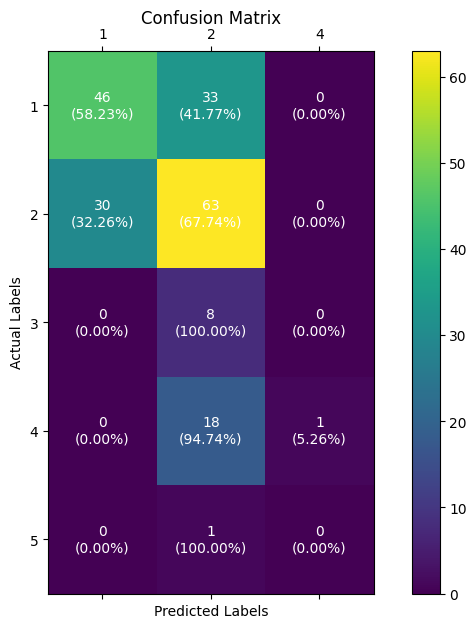

In [24]:
accuracy = model.score(X_test, y_test)
print(f'Accuracy: {accuracy}')

# make confusion matrix
y_pred = model.predict(X_test)
confusion_matrix = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
confusion_matrix_percentage = confusion_matrix.div(confusion_matrix.sum(axis=1), axis=0) * 100
print(confusion_matrix)

plt.figure(figsize=(10, 7))
plt.matshow(confusion_matrix, cmap='viridis', fignum=1)

plt.colorbar()

plt.title('Confusion Matrix', pad=20)
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')

plt.xticks(ticks=range(len(confusion_matrix.columns)), labels=confusion_matrix.columns)
plt.yticks(ticks=range(len(confusion_matrix.index)), labels=confusion_matrix.index)

for (i, j), value in np.ndenumerate(confusion_matrix):
    percentage = confusion_matrix_percentage.iloc[i, j]
    plt.text(j, i, f'{value}\n({percentage:.2f}%)', ha='center', va='center', color='white')

plt.show()

In [25]:
y_output = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred})

y_output.to_csv(f'logistic_regression_output_{BONE}.csv', index=False)

### Extracting the feature importance

In [26]:
coefficients = model.coef_  # Shape will be (n_classes, n_features)
feature_importance = np.abs(coefficients).mean(axis=0)  # Average importance across all classes
coefficients

array([[ 0.25946367,  0.60598685,  0.        ,  0.        , -0.73727473,
         0.80551033,  1.15873693, -1.7091383 ,  0.36817306,  0.68830155,
         0.05879203, -0.15753294,  0.        ],
       [ 0.        ,  0.        , -0.04787629, -0.16247302, -0.16345584,
         0.05918351,  0.0048064 ,  0.        , -0.04364264,  0.48989622,
         0.        ,  0.35458577,  0.        ],
       [ 0.        ,  0.        ,  0.00887738,  0.07783421,  0.40918694,
         0.4109391 , -0.47092042,  0.37207339,  0.25407682, -0.21426154,
         0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.11376169,  0.14698306,  0.03410812,
        -0.98736467, -0.21799754,  0.22162423,  0.        , -0.40698655,
         0.05531403,  0.        ,  0.66944164],
       [-0.26697751, -0.92939188, -0.20859564, -0.21164167,  0.        ,
        -1.21824314,  0.        ,  0.        , -0.66520952,  0.        ,
        -0.19492301, -0.11935521, -0.14625155]])

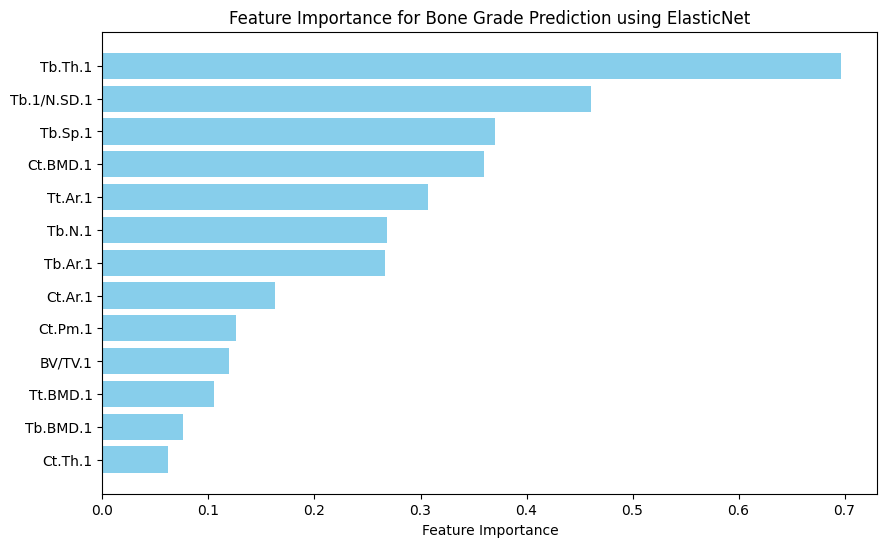

In [27]:
import matplotlib.pyplot as plt

if BONE == 'tibia':
    feature_names = tibia_columns
else:
    feature_names = radius_columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Feature Importance')
plt.title('Feature Importance for Bone Grade Prediction using ElasticNet')
plt.gca().invert_yaxis()
plt.show()


### Make Precision-Recall curves of each class

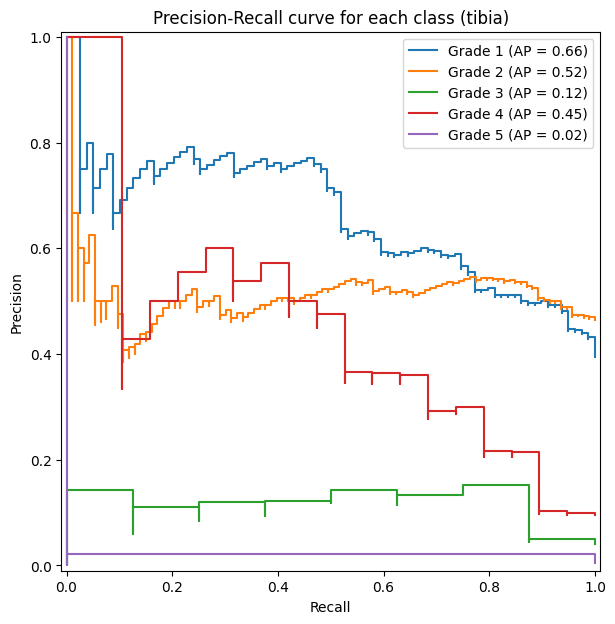

In [28]:
y_pred_proba = model.predict_proba(X_test)
n_classes = y_pred_proba.shape[1]
classes_names = {}

# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.arange(n_classes+1))

# Compute precision-recall curve and average precision for each class
precision = dict()
recall = dict()
average_precision = dict()

for i in range(1, n_classes+1):
    # find out class name by seeing what is the true class in y_test_binarized and comparing it to the index in y_true
    precision[i], recall[i], _ = precision_recall_curve(y_test_binarized[:, i], y_pred_proba[:, i-1])
    average_precision[i] = average_precision_score(y_test_binarized[:, i], y_pred_proba[:, i-1])

# Plot the precision-recall curve for each class
plt.figure(figsize=(10, 7))

for i in range(1, n_classes+1):
    display = PrecisionRecallDisplay(precision=precision[i], recall=recall[i], average_precision=average_precision[i])
    display.plot(ax=plt.gca(), name=f'Grade {i}')

plt.title(f'Precision-Recall curve for each class ({BONE})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='best')
plt.show()